In [1]:
import xarray as xr
import xskillscore
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.io.shapereader
from scipy import stats
import re

os.makedirs("figures/RPSS drivers ELR", exist_ok=True)

## Load and align data (ELR)

In [2]:
obs_elr   = xr.open_dataarray('outputs/Full Period/GEFS_IMD/ELR_y_test_wk3-4.nc')
preds_elr = xr.open_dataarray('outputs/Full Period/GEFS_IMD/ELR_predictions_wk3-4.nc')
obs_unet  = xr.open_dataarray('outputs/Full Period/GEFS_IMD/unet_ytest_raw_wk3-4.nc')

# obs_elr:   (bootstrap, T=638, Y, X, category) — one-hot, datetime T, NaN-padded
# preds_elr: (bootstrap, T=198, Y, X, category) — probabilities, integer T 0..197
# For each bootstrap: 198 of obs_elr's T entries are non-NaN; those datetimes are preds_elr's true T.

real_X = obs_unet.X
real_Y = obs_unet.Y

obs_list, preds_list = [], []
for b in range(len(obs_elr.bootstrap)):
    obs_b      = obs_elr.isel(bootstrap=b)
    valid_mask = ~obs_b.isnull().all(dim=("Y","X","category"))
    valid_T    = obs_b['T'][valid_mask].values
    obs_list.append(obs_b.isel(T=valid_mask))
    preds_list.append(preds_elr.isel(bootstrap=b).assign_coords(T=valid_T))

obs_elrM   = xr.concat(obs_list,   dim="bootstrap").mean(dim="bootstrap")   # (T, Y, X, cat)
preds_elrM = xr.concat(preds_list, dim="bootstrap").mean(dim="bootstrap")   # (T, Y, X, cat)

valid_t    = ~obs_elrM.isnull().all(dim=("Y","X","category"))
obs_elrM   = obs_elrM.sel(T=valid_t)
preds_elrM = preds_elrM.sel(T=obs_elrM['T'])

obs_elrM   = obs_elrM.assign_coords(X=real_X, Y=real_Y)
preds_elrM = preds_elrM.assign_coords(X=real_X, Y=real_Y)

# Reuse obs_oheM name for downstream cells (kept identical to RPSS_drivers.ipynb)
obs_oheM = obs_elrM

land_mask = preds_elr.isel(bootstrap=0, category=0).isnull().all(dim='T')
land_mask = land_mask.assign_coords(X=real_X, Y=real_Y)

print("obs_elrM   shape:", obs_elrM.shape)
print("preds_elrM shape:", preds_elrM.shape)
print("T range:", str(pd.Timestamp(obs_elrM['T'].values[0]))[:10],
      "to", str(pd.Timestamp(obs_elrM['T'].values[-1]))[:10])

obs_elrM   shape: (638, 32, 32, 3)
preds_elrM shape: (638, 32, 32, 3)
T range: 1989-05-25 to 2018-10-18


## ELR RPSS — aggregated formulation

$$\text{RPSS}(\mathbf{x}) = 1 - \frac{\sum_t \text{RPS}_t(\mathbf{x})}{\sum_t \text{RPS}^{\text{clim}}_t(\mathbf{x})}$$

In [3]:
obs_r  = obs_oheM.transpose('T','Y','X','category')
fcast  = preds_elrM.transpose('T','Y','X','category')
climo  = xr.full_like(fcast, 1/3)

rps_model = xskillscore.rps(obs_r, fcast, dim='T', category_edges=None, input_distributions='p')
rps_climo = xskillscore.rps(obs_r, climo, dim='T', category_edges=None, input_distributions='p')

rpss = (1 - rps_model / rps_climo).where(~land_mask).assign_coords(X=real_X, Y=real_Y)

print("ELR RPSS range:", float(rpss.min().values), "to", float(rpss.max().values))

ELR RPSS range: -0.005469961385415445 to 0.050489474560068026


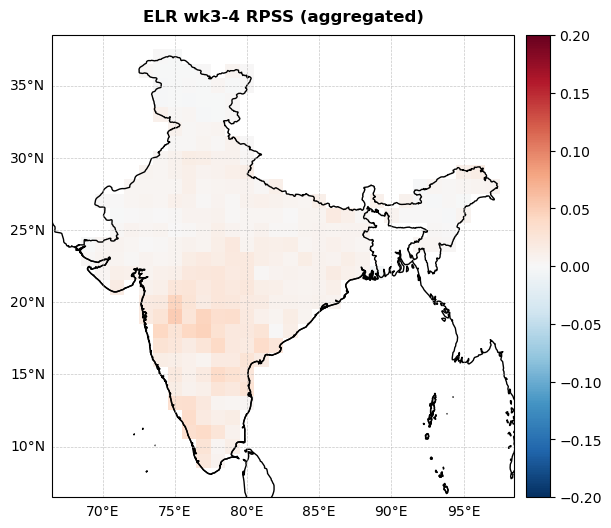

In [4]:
def plot_map(da, title="", cmap="RdBu_r", vmin=-0.2, vmax=0.2):
    fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': ccrs.PlateCarree()})
    im = da.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap,
                 vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.coastlines()
    reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
    ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                      facecolor='none', edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, alpha=0.7)
    gl.top_labels = False; gl.right_labels = False
    plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02, fraction=0.05)
    plt.show()

plot_map(rpss, title="ELR wk3-4 RPSS (aggregated)")

# MJO

In [5]:
mjo = pd.read_csv(
    "download/mjo.txt", skiprows=2, sep=r'\s+', header=None,
    names=["year","month","day","RMM1","RMM2","phase","amplitude","method","extra"],
    na_values=[1e35, 999]
).drop(columns="extra", errors="ignore")
mjo["date"] = pd.to_datetime(dict(year=mjo.year, month=mjo.month, day=mjo.day), errors="coerce")
mjo = mjo[(mjo['date'] >= '1980-01-01') & (mjo['date'] <= '2025-12-31')].set_index('date')

df_mjo_roll = mjo[['RMM1','RMM2']].rolling(window=15, center=True, min_periods=1).mean()
mjo_xr = df_mjo_roll.to_xarray()

rpss_dates = pd.to_datetime(obs_oheM['T'].values)
rmm1 = mjo_xr['RMM1'].sel(date=rpss_dates, method='nearest').values
rmm2 = mjo_xr['RMM2'].sel(date=rpss_dates, method='nearest').values
phase_num = (((np.arctan2(rmm2, rmm1) + 2*np.pi) % (2*np.pi)) // (np.pi/4) + 1).astype(int)
phase_da  = xr.DataArray(phase_num, dims=('T',), coords={'T': obs_oheM['T']})
print("Phase counts:", {int(p): int((phase_da==p).sum()) for p in range(1,9)})

Phase counts: {1: 75, 2: 78, 3: 54, 4: 71, 5: 114, 6: 104, 7: 70, 8: 72}


## ELR RPSS per MJO phase

In [6]:
rpss_mjo = {}
for phase in range(1, 9):
    mask_t = (phase_da == phase).values
    if mask_t.sum() < 3:
        continue
    obs_ph   = obs_r.isel(T=mask_t)
    fcast_ph = fcast.isel(T=mask_t)
    climo_ph = climo.isel(T=mask_t)
    rps_m = xskillscore.rps(obs_ph, fcast_ph, dim='T', category_edges=None, input_distributions='p')
    rps_c = xskillscore.rps(obs_ph, climo_ph, dim='T', category_edges=None, input_distributions='p')
    rpss_mjo[phase] = (1 - rps_m / rps_c).where(~land_mask)

print("Phases computed:", list(rpss_mjo.keys()))

Phases computed: [1, 2, 3, 4, 5, 6, 7, 8]


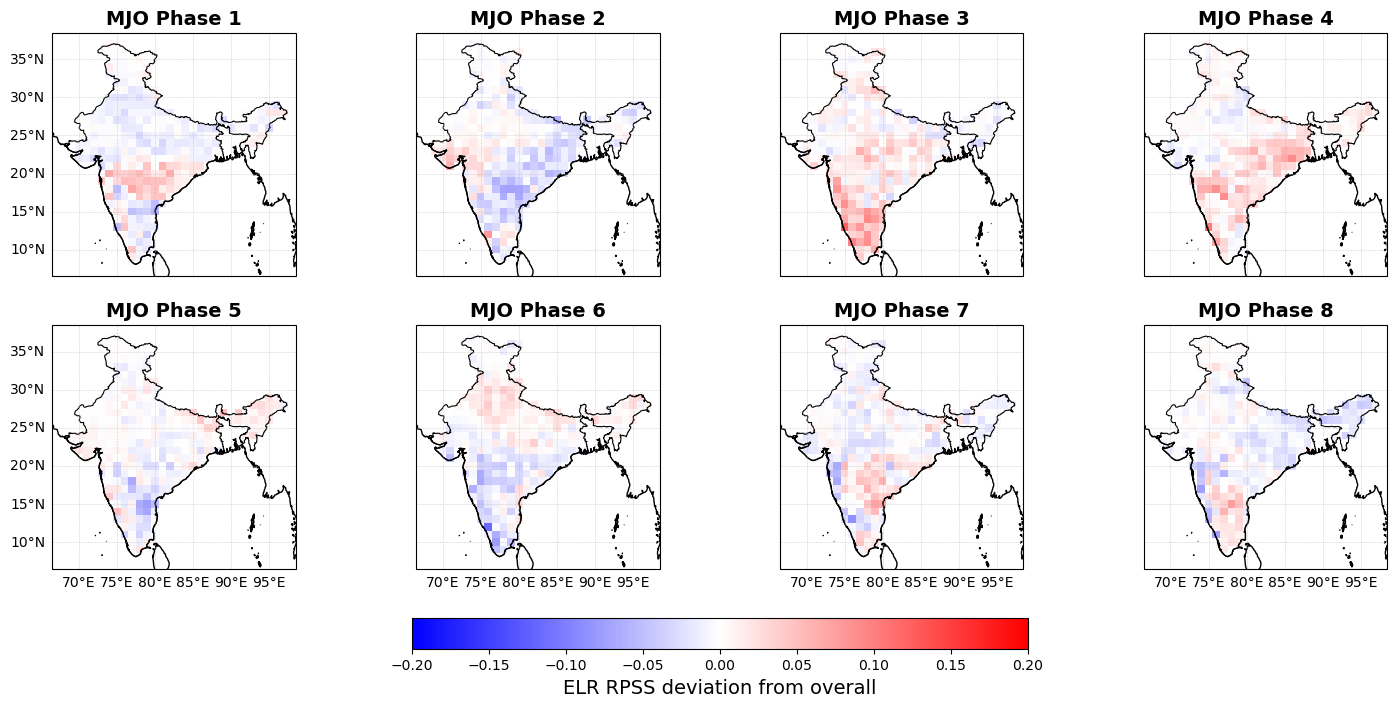

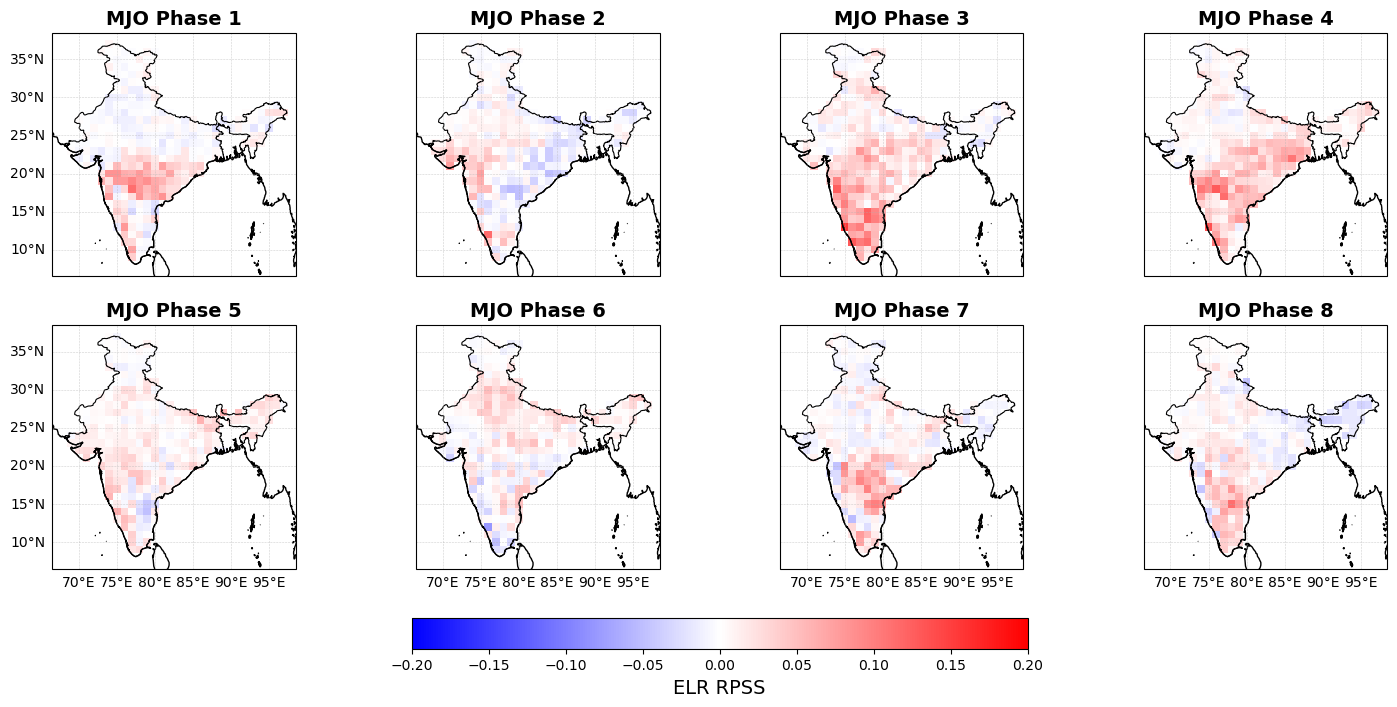

In [7]:
def plot_mjo_phases(rpss_dict, demean=True, rpss_ref=None,
                   vmin=-0.2, vmax=0.2, cmap='bwr', fname=None):
    if rpss_ref is None:
        rpss_ref = rpss
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18,8),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    axes = axes.flatten(); mappable = None

    for i, phase in enumerate(range(1,9)):
        ax  = axes[i]
        val = rpss_dict[phase]
        if demean:
            val = val - rpss_ref
        im = val.plot(ax=ax, transform=ccrs.PlateCarree(),
                      cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
        if mappable is None: mappable = im
        ax.coastlines()
        reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
        ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                          facecolor='none', edgecolor='black', linewidth=0.8)
        ax.set_title(f"MJO Phase {phase}", fontsize=14, fontweight="bold", pad=6)
        gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, alpha=0.6)
        gl.top_labels = False; gl.right_labels = False
        if i % 4 != 0: gl.left_labels = False
        if i < 4:      gl.bottom_labels = False
        gl.xlabel_style = {"size":10}; gl.ylabel_style = {"size":10}

    cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal", fraction=0.05, pad=0.08)
    cbar.set_label("ELR RPSS deviation from overall" if demean else "ELR RPSS", fontsize=14)
    if fname:
        plt.savefig(f"figures/RPSS drivers ELR/{fname}", dpi=300, bbox_inches="tight")
    plt.show()

plot_mjo_phases(rpss_mjo, demean=True,  fname="RPSS_ELR_MJO_deviation.pdf")
plot_mjo_phases(rpss_mjo, demean=False, vmin=-0.2, vmax=0.2, fname="RPSS_ELR_MJO_plain.pdf")

## MJO composite maps with stippling (phase vs all, p < 0.10)

C:\Users\emile\AppData\Local\Temp\ipykernel_27724\550095151.py:11: RuntimeWarning: Mean of empty slice
  ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
C:\Users\emile\anaconda3\envs\s2s-cnn\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\emile\AppData\Local\Temp\ipykernel_27724\550095151.py:11: RuntimeWarning: Mean of empty slice
  ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
C:\Users\emile\anaconda3\envs\s2s-cnn\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\emile\AppData\Local\Temp\ipykernel_27724\550095151.py:11: RuntimeWarning: Mean of empty slice
  ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
C:\Users\emile\anaconda3\envs\s2s-cnn\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning:

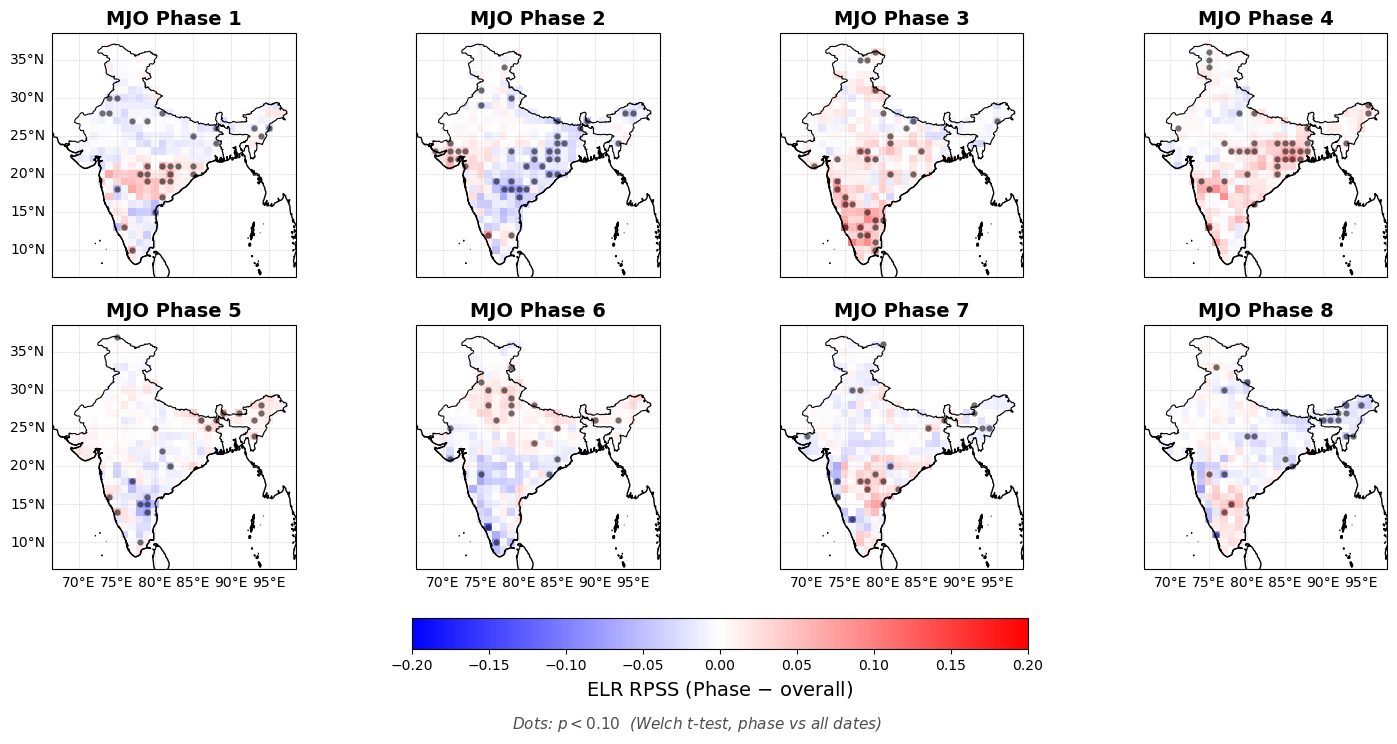

In [8]:
fc_cdf    = fcast.cumsum(dim="category")
obs_cdf   = obs_r.cumsum(dim="category")
climo_cdf = climo.cumsum(dim="category")
rps_per_t       = ((fc_cdf  - obs_cdf)**2).sum(dim="category")
rps_climo_per_t = ((climo_cdf - obs_cdf)**2).sum(dim="category")
rpss_per_t = (1 - rps_per_t / rps_climo_per_t).where(~land_mask)

def ttest_2samp_grid(a, b):
    na  = (~np.isnan(a)).sum(axis=0)
    nb_ = (~np.isnan(b)).sum(axis=0)
    ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
    sa = np.nanstd(a, axis=0, ddof=1)**2 / np.maximum(na,  1)
    sb = np.nanstd(b, axis=0, ddof=1)**2 / np.maximum(nb_, 1)
    se = np.sqrt(sa + sb)
    t  = (ma - mb) / np.where(se > 0, se, np.nan)
    df = (sa + sb)**2 / (sa**2 / np.maximum(na-1,1) + sb**2 / np.maximum(nb_-1,1))
    p  = 2 * stats.t.sf(np.abs(t), df=df)
    return np.where((na < 3) | (nb_ < 3), np.nan, p)

rpss_vals = rpss_per_t.values

mjo_pval = {}
for phase in range(1, 9):
    mask_t = (phase_da == phase).values
    mjo_pval[phase] = xr.DataArray(
        ttest_2samp_grid(rpss_vals[mask_t], rpss_vals),
        dims=["Y","X"], coords={"Y": rpss.Y, "X": rpss.X}
    )

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18,8),
                         subplot_kw={"projection": ccrs.PlateCarree()})
axes = axes.flatten(); mappable = None

for i, phase in enumerate(range(1,9)):
    ax   = axes[i]
    diff = rpss_mjo[phase] - rpss
    im   = diff.plot(ax=ax, transform=ccrs.PlateCarree(),
                     cmap='bwr', vmin=-0.2, vmax=0.2, add_colorbar=False)
    if mappable is None: mappable = im

    pv = mjo_pval[phase]
    sig = (pv < 0.10).values
    lon2d, lat2d = np.meshgrid(pv["X"].values, pv["Y"].values)
    ax.scatter(lon2d[sig], lat2d[sig], s=20, c="black", alpha=0.55,
               linewidths=0, transform=ccrs.PlateCarree(), zorder=5)

    ax.coastlines()
    reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
    ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                      facecolor='none', edgecolor='black', linewidth=0.8)
    ax.set_title(f"MJO Phase {phase}", fontsize=14, fontweight="bold", pad=6)
    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, alpha=0.6)
    gl.top_labels = False; gl.right_labels = False
    if i % 4 != 0: gl.left_labels = False
    if i < 4:      gl.bottom_labels = False
    gl.xlabel_style = {"size":10}; gl.ylabel_style = {"size":10}

cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal", fraction=0.05, pad=0.08)
cbar.set_label("ELR RPSS (Phase $-$ overall)", fontsize=14)
fig.text(0.5, 0.01, r"Dots: $p < 0.10$  (Welch t-test, phase vs all dates)",
         ha="center", fontsize=11, style="italic", color="0.3")
plt.savefig("figures/RPSS drivers ELR/RPSS_ELR_MJO_composite_sig.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ENSO

In [9]:
records = []
pattern = re.compile(r"[+-]?\d+\.\d+")
with open("download/sst_weekly.txt") as f:
    for line in f:
        if re.match(r"\s*\d{2}[A-Z]{3}\d{4}", line):
            date = line.split()[0]
            nums = list(map(float, pattern.findall(line)))
            if len(nums) == 8:
                records.append([date] + nums)

cols = ["Week","Nino12_SST","Nino12_SSTA","Nino3_SST","Nino3_SSTA",
        "Nino34_SST","Nino34_SSTA","Nino4_SST","Nino4_SSTA"]
nino = pd.DataFrame(records, columns=cols)
nino["Week"] = pd.to_datetime(nino["Week"], format="%d%b%Y")
nino = nino.set_index("Week").rolling(window=2, center=True, min_periods=1).mean()
nino_xr = nino.to_xarray()

nino4_vals = nino_xr["Nino4_SSTA"].sel(Week=rpss_dates, method="nearest").values

enso4_da = xr.DataArray(xr.where(xr.DataArray(nino4_vals, dims='T') >=  0.5, 1,
                          xr.where(xr.DataArray(nino4_vals, dims='T') <= -0.5, -1, 0)).values,
                         dims=('T',), coords={'T': obs_oheM['T']})

print("ENSO4 counts:", {int(v): int((enso4_da==v).sum()) for v in [-1,0,1]})

ENSO4 counts: {-1: 135, 0: 425, 1: 78}


## ELR RPSS per ENSO mode + composite stippling maps

In [10]:
def rpss_by_enso(mode_da):
    out = {}
    for mode in [-1, 0, 1]:
        mask_t = (mode_da == mode).values
        if mask_t.sum() < 3: continue
        rps_m = xskillscore.rps(obs_r.isel(T=mask_t), fcast.isel(T=mask_t),
                                dim='T', category_edges=None, input_distributions='p')
        rps_c = xskillscore.rps(obs_r.isel(T=mask_t), climo.isel(T=mask_t),
                                dim='T', category_edges=None, input_distributions='p')
        out[mode] = (1 - rps_m / rps_c).where(~land_mask)
    return out

rpss_enso4 = rpss_by_enso(enso4_da)
print("Done.")

Done.


C:\Users\emile\AppData\Local\Temp\ipykernel_27724\550095151.py:11: RuntimeWarning: Mean of empty slice
  ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
C:\Users\emile\anaconda3\envs\s2s-cnn\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\emile\AppData\Local\Temp\ipykernel_27724\550095151.py:11: RuntimeWarning: Mean of empty slice
  ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
C:\Users\emile\anaconda3\envs\s2s-cnn\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\emile\AppData\Local\Temp\ipykernel_27724\550095151.py:11: RuntimeWarning: Mean of empty slice
  ma, mb = np.nanmean(a, axis=0), np.nanmean(b, axis=0)
C:\Users\emile\anaconda3\envs\s2s-cnn\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning:

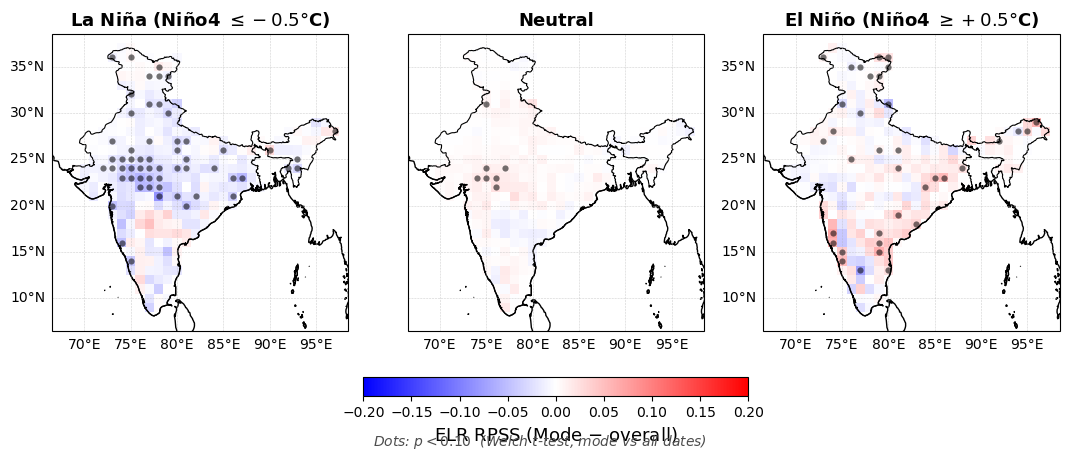

In [11]:
def plot_enso_sig(rpss_enso, mode_da, titles, fname, alpha=0.10):
    enso_pval = {}
    for mode in [-1, 0, 1]:
        mask_t = (mode_da == mode).values
        enso_pval[mode] = xr.DataArray(
            ttest_2samp_grid(rpss_vals[mask_t], rpss_vals),
            dims=["Y","X"], coords={"Y": rpss.Y, "X": rpss.X}
        )

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13,5),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    mappable = None

    for i, mode in enumerate([-1, 0, 1]):
        ax   = axes[i]
        diff = rpss_enso[mode] - rpss
        im   = diff.plot(ax=ax, transform=ccrs.PlateCarree(),
                         cmap='bwr', vmin=-0.2, vmax=0.2, add_colorbar=False)
        if mappable is None: mappable = im

        pv  = enso_pval[mode]
        sig = (pv < alpha).values
        lon2d, lat2d = np.meshgrid(pv["X"].values, pv["Y"].values)
        ax.scatter(lon2d[sig], lat2d[sig], s=20, c="black", alpha=0.55,
                   linewidths=0, transform=ccrs.PlateCarree(), zorder=5)

        ax.coastlines()
        reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
        ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                          facecolor='none', edgecolor='black', linewidth=0.8)
        ax.set_title(titles[mode], fontsize=13, fontweight="bold", pad=6)
        gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, alpha=0.6)
        gl.top_labels = False; gl.right_labels = False
        if i == 1: gl.left_labels = False
        gl.xlabel_style = {"size":10}; gl.ylabel_style = {"size":10}

    cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal", fraction=0.05, pad=0.12)
    cbar.set_label("ELR RPSS (Mode $-$ overall)", fontsize=13)
    fig.text(0.5, 0.01, r"Dots: $p < 0.10$  (Welch t-test, mode vs all dates)",
             ha="center", fontsize=10, style="italic", color="0.3")
    plt.savefig(f"figures/RPSS drivers ELR/{fname}", dpi=300, bbox_inches="tight")
    plt.show()

nino4_titles = {-1: r"La Niña (Niño4 $\leq -0.5°$C)", 0: "Neutral",
                  1: r"El Niño (Niño4 $\geq +0.5°$C)"}

plot_enso_sig(rpss_enso4, enso4_da, nino4_titles, "RPSS_ELR_ENSO4_composite_sig.pdf")

## Plain RPSS per ENSO mode (Niño4)

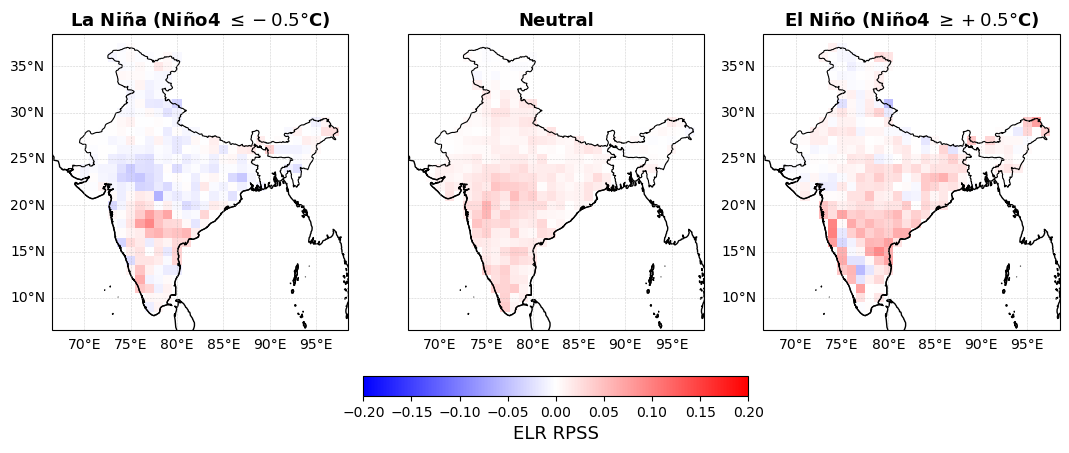

In [12]:
def plot_enso_plain(rpss_enso, titles, fname):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 5),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    mappable = None

    for i, mode in enumerate([-1, 0, 1]):
        ax  = axes[i]
        val = rpss_enso[mode]

        im = val.plot(ax=ax, transform=ccrs.PlateCarree(),
                      cmap='bwr', vmin=-0.2, vmax=0.2, add_colorbar=False)
        if mappable is None:
            mappable = im

        ax.coastlines()
        reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
        ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                          facecolor='none', edgecolor='black', linewidth=0.8)
        ax.set_title(titles[mode], fontsize=13, fontweight="bold", pad=6)

        gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, alpha=0.6)
        gl.top_labels = False; gl.right_labels = False
        if i == 1: gl.left_labels = False
        gl.xlabel_style = {"size": 10}; gl.ylabel_style = {"size": 10}

    cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal",
                        fraction=0.05, pad=0.12)
    cbar.set_label("ELR RPSS", fontsize=13)
    plt.savefig(f"figures/RPSS drivers ELR/{fname}", dpi=300, bbox_inches="tight")
    plt.show()

plot_enso_plain(rpss_enso4, nino4_titles, "RPSS_ELR_ENSO4_plain.pdf")

## Box plots

C:\Users\emile\AppData\Local\Temp\ipykernel_27724\1649541562.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_enso, x="Category", y="RPSS",
C:\Users\emile\AppData\Local\Temp\ipykernel_27724\1649541562.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mjo, x="Category", y="RPSS",


C:\Users\emile\AppData\Local\Temp\ipykernel_27724\1649541562.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


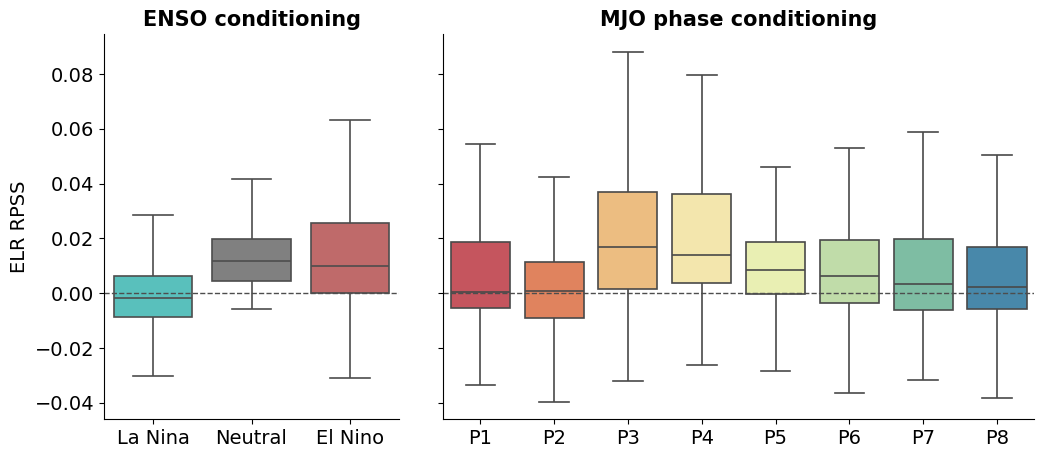

In [13]:
rows_mjo, rows_enso = [], []
for phase in range(1, 9):
    vals = rpss_mjo[phase].values.ravel()
    for v in vals[~np.isnan(vals)]:
        rows_mjo.append({"Category": f"P{phase}", "RPSS": v})

for mode, lb in [(-1, "La Nina"), (0, "Neutral"), (1, "El Nino")]:
    vals = rpss_enso4[mode].values.ravel()
    for v in vals[~np.isnan(vals)]:
        rows_enso.append({"Category": lb, "RPSS": v})

df_mjo  = pd.DataFrame(rows_mjo)
df_enso = pd.DataFrame(rows_enso)

fig, axes = plt.subplots(ncols=2, figsize=(12, 5), sharey=True,
                         gridspec_kw={"width_ratios": [1, 2], "wspace": 0.1})

sns.boxplot(data=df_enso, x="Category", y="RPSS",
            order=["La Nina", "Neutral", "El Nino"],
            palette=['mediumturquoise', 'gray', 'indianred'],
            showfliers=False, ax=axes[0], linewidth=1.2)
axes[0].set_title("ENSO conditioning", fontweight="bold", fontsize=15)
axes[0].set_xlabel("")
axes[0].set_ylabel("ELR RPSS", fontsize=14)

sns.boxplot(data=df_mjo, x="Category", y="RPSS",
            palette=sns.color_palette("Spectral", 8),
            showfliers=False, ax=axes[1], linewidth=1.2)
axes[1].set_title("MJO phase conditioning", fontweight="bold", fontsize=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

for ax in axes:
    ax.axhline(0, color="0.3", linestyle="--", linewidth=1)
    ax.tick_params(axis="x", labelsize=14, rotation=0)
axes[0].tick_params(axis="y", labelsize=14)

sns.despine()
plt.tight_layout()
plt.savefig("figures/RPSS drivers ELR/RPSS_ELR_MJO_ENSO_boxplot.pdf", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\emile\AppData\Local\Temp\ipykernel_27724\658187921.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


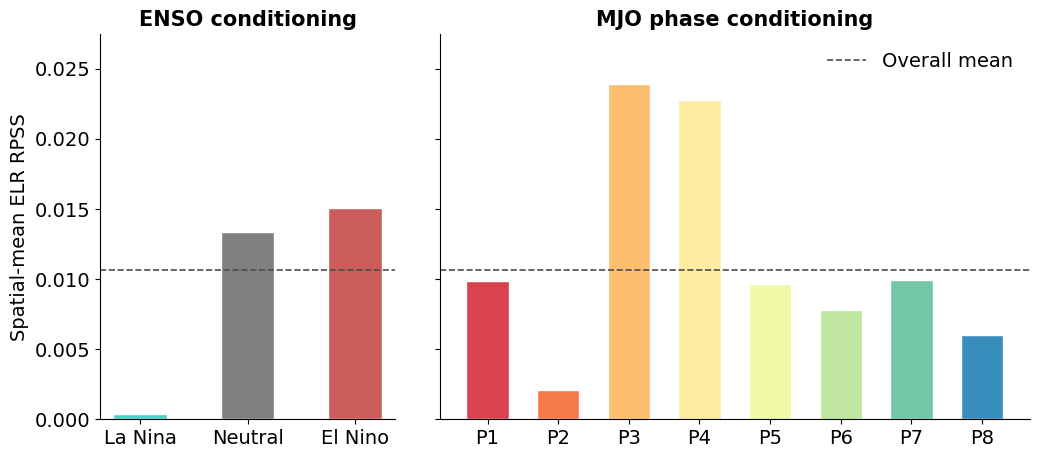

In [14]:
rows_mjo_sp, rows_enso_sp = [], []
for phase in range(1, 9):
    rows_mjo_sp.append({"Category": f"P{phase}", "RPSS": float(rpss_mjo[phase].mean().values)})

for mode, lb in [(-1, "La Nina"), (0, "Neutral"), (1, "El Nino")]:
    rows_enso_sp.append({"Category": lb, "RPSS": float(rpss_enso4[mode].mean().values)})

df_mjo_sp  = pd.DataFrame(rows_mjo_sp)
df_enso_sp = pd.DataFrame(rows_enso_sp)

fig, axes = plt.subplots(ncols=2, figsize=(12, 5), sharey=True,
                         gridspec_kw={"width_ratios": [1, 2], "wspace": 0.1})

enso_order  = ["La Nina", "Neutral", "El Nino"]
enso_colors = ['mediumturquoise', 'gray', 'indianred']
mjo_colors  = sns.color_palette("Spectral", 8)

axes[0].bar(enso_order, df_enso_sp["RPSS"], color=enso_colors, edgecolor='white', width=0.5)
axes[0].axhline(float(rpss.mean().values), color='0.3', ls='--', lw=1.2, label='Overall mean')
axes[0].set_title("ENSO conditioning", fontweight="bold", fontsize=15)
axes[0].set_ylabel("Spatial-mean ELR RPSS", fontsize=14)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", labelsize=14)

axes[1].bar(df_mjo_sp["Category"], df_mjo_sp["RPSS"], color=mjo_colors, edgecolor='white', width=0.6)
axes[1].axhline(float(rpss.mean().values), color='0.3', ls='--', lw=1.2, label='Overall mean')
axes[1].set_title("MJO phase conditioning", fontweight="bold", fontsize=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", labelsize=14)
axes[1].legend(fontsize=14, frameon=False)

# Flexible y-range based on actual values
all_vals = df_mjo_sp["RPSS"].tolist() + df_enso_sp["RPSS"].tolist() + [float(rpss.mean().values)]
ymin = min(0, min(all_vals))
ymax = max(all_vals) * 1.15
for ax in axes:
    ax.axhline(0, color='0.7', ls=':', lw=1)
    ax.set_ylim(ymin, ymax)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis="y", labelsize=14)

plt.tight_layout()
plt.savefig("figures/RPSS drivers ELR/RPSS_ELR_MJO_ENSO_barchart.pdf", dpi=300, bbox_inches="tight")
plt.show()

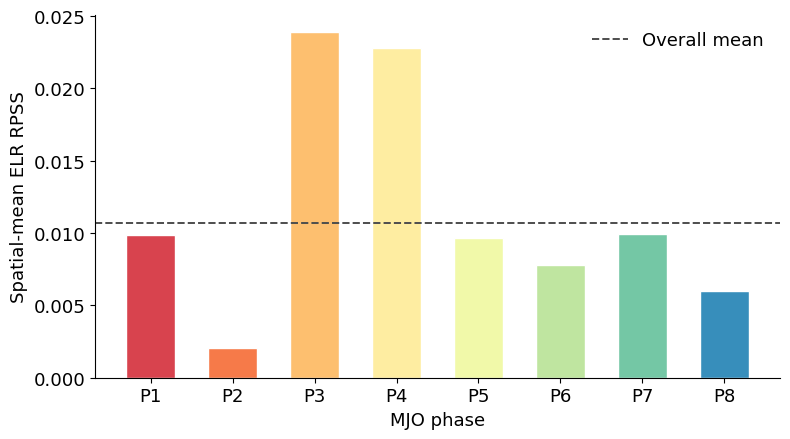

In [15]:
mjo_means    = [float(rpss_mjo[ph].mean().values) for ph in range(1, 9)]
overall_mean = float(rpss.mean().values)
mjo_colors   = sns.color_palette("Spectral", 8)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(range(1, 9), mjo_means, color=mjo_colors, edgecolor='white', width=0.6)
ax.axhline(overall_mean, color='0.3', ls='--', lw=1.4, label='Overall mean')
ax.set_xticks(range(1, 9))
ax.set_xticklabels([f"P{p}" for p in range(1, 9)], fontsize=13)
ax.set_xlabel("MJO phase", fontsize=13)
ax.set_ylabel("Spatial-mean ELR RPSS", fontsize=13)
ax.tick_params(axis="y", labelsize=13)
ax.legend(fontsize=13, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("figures/RPSS drivers ELR/RPSS_ELR_MJO_barchart.pdf", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\emile\AppData\Local\Temp\ipykernel_27724\4032138854.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


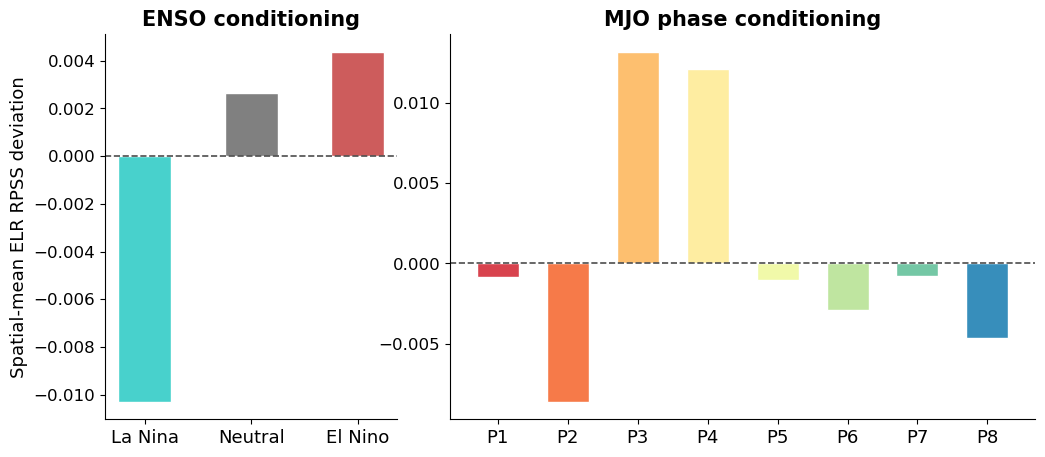

In [16]:
enso_order  = ["La Nina", "Neutral", "El Nino"]
enso_colors = ['mediumturquoise', 'gray', 'indianred']
mjo_colors  = sns.color_palette("Spectral", 8)

enso_dev_means = {}
for mode, lb in [(-1, "La Nina"), (0, "Neutral"), (1, "El Nino")]:
    dev = rpss_enso4[mode] - rpss
    enso_dev_means[lb] = float(dev.mean().values)

mjo_dev_means = []
for ph in range(1, 9):
    dev = rpss_mjo[ph] - rpss
    mjo_dev_means.append(float(dev.mean().values))

fig, axes = plt.subplots(ncols=2, figsize=(12, 5),
                         gridspec_kw={"width_ratios": [1, 2], "wspace": 0.12})

axes[0].bar(enso_order, [enso_dev_means[lb] for lb in enso_order],
            color=enso_colors, edgecolor='white', width=0.5)
axes[0].axhline(0, color='0.3', ls='--', lw=1.2)
axes[0].set_title("ENSO conditioning", fontweight="bold", fontsize=15)
axes[0].set_ylabel("Spatial-mean ELR RPSS deviation", fontsize=13)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", labelsize=13)
axes[0].tick_params(axis="y", labelsize=12)
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].bar(range(1, 9), mjo_dev_means, color=mjo_colors, edgecolor='white', width=0.6)
axes[1].axhline(0, color='0.3', ls='--', lw=1.2)
axes[1].set_title("MJO phase conditioning", fontweight="bold", fontsize=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_xticks(range(1, 9))
axes[1].set_xticklabels([f"P{p}" for p in range(1, 9)], fontsize=13)
axes[1].tick_params(axis="y", labelsize=12)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("figures/RPSS drivers ELR/RPSS_ELR_MJO_ENSO_deviation_barchart.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Combined MJO phase × ENSO mode stratification

In [17]:
amplitude = np.sqrt(rmm1**2 + rmm2**2)
amplitude_da = xr.DataArray(amplitude, dims=('T',), coords={'T': obs_oheM['T']})

active_da = amplitude_da >= 1.0
print(f"Active MJO dates: {int(active_da.sum())} / {len(active_da)}")
print("Phase counts (active only):")
for ph in range(1, 9):
    n = int(((phase_da == ph) & active_da).sum())
    print(f"  Phase {ph}: {n}")

Active MJO dates: 256 / 638
Phase counts (active only):
  Phase 1: 33
  Phase 2: 28
  Phase 3: 23
  Phase 4: 31
  Phase 5: 53
  Phase 6: 49
  Phase 7: 17
  Phase 8: 22


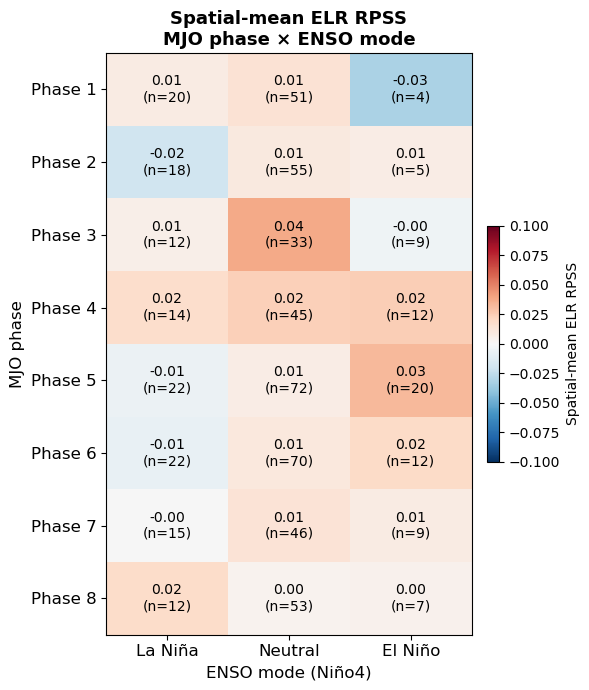

In [18]:
enso_modes  = [-1, 0, 1]
enso_labels = {-1: "La Niña", 0: "Neutral", 1: "El Niño"}
grid   = np.full((8, 3), np.nan)
n_grid = np.zeros((8, 3), dtype=int)

for pi, phase in enumerate(range(1, 9)):
    for ei, mode in enumerate(enso_modes):
        mask_t = ((phase_da == phase) & (enso4_da == mode)).values
        n = mask_t.sum()
        n_grid[pi, ei] = n
        if n < 3:
            continue
        rps_m = xskillscore.rps(obs_r.isel(T=mask_t), fcast.isel(T=mask_t),
                                dim='T', category_edges=None, input_distributions='p')
        rps_c = xskillscore.rps(obs_r.isel(T=mask_t), climo.isel(T=mask_t),
                                dim='T', category_edges=None, input_distributions='p')
        rpss_combo = (1 - rps_m / rps_c).where(~land_mask)
        grid[pi, ei] = float(rpss_combo.mean().values)

fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(grid, aspect='auto', cmap='RdBu_r', vmin=-0.1, vmax=0.1)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["La Niña", "Neutral", "El Niño"], fontsize=12)
ax.set_yticks(range(8))
ax.set_yticklabels([f"Phase {p}" for p in range(1, 9)], fontsize=12)
ax.set_xlabel("ENSO mode (Niño4)", fontsize=12)
ax.set_ylabel("MJO phase", fontsize=12)
ax.set_title("Spatial-mean ELR RPSS\nMJO phase × ENSO mode", fontsize=13, fontweight="bold")

for pi in range(8):
    for ei in range(3):
        val = grid[pi, ei]
        n   = n_grid[pi, ei]
        txt = f"{val:.2f}\n(n={n})" if not np.isnan(val) else f"n={n}"
        col = "white" if abs(val) > 0.06 else "black" if not np.isnan(val) else "0.5"
        ax.text(ei, pi, txt, ha='center', va='center', fontsize=10, color=col)

plt.colorbar(im, ax=ax, orientation='vertical', label='Spatial-mean ELR RPSS', fraction=0.03, pad=0.04)
plt.tight_layout()
plt.savefig("figures/RPSS drivers ELR/RPSS_ELR_MJO_ENSO_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()

Sample sizes:
  El Niño + active MJO: n=36
  Neutral + active MJO: n=169
  La Niña + active MJO: n=51
  All active MJO: n=256
  All dates: n=638


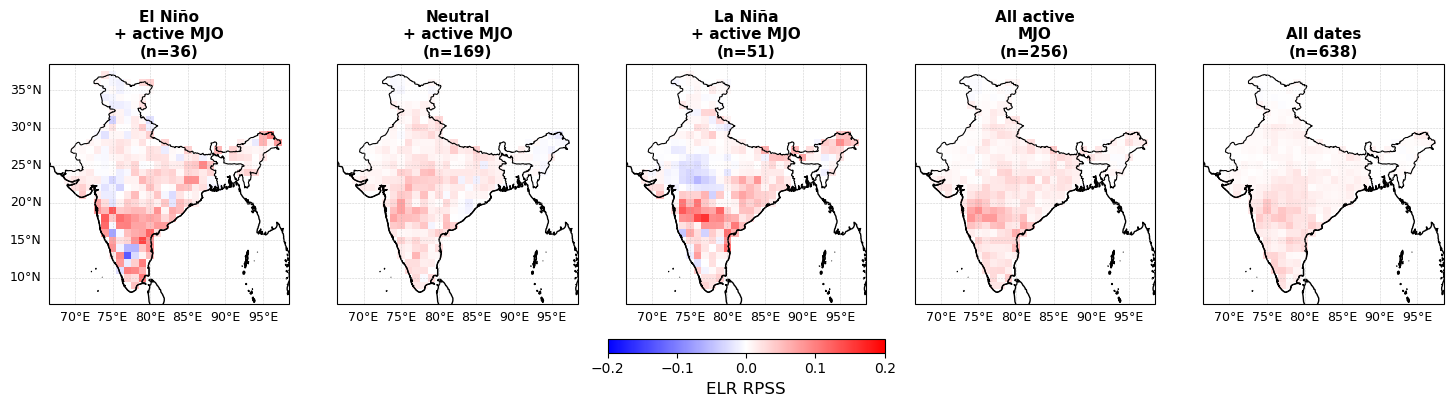

In [19]:
regimes = {
    "El Niño\n+ active MJO":  (enso4_da ==  1) & active_da,
    "Neutral\n+ active MJO":  (enso4_da ==  0) & active_da,
    "La Niña\n+ active MJO":  (enso4_da == -1) & active_da,
    "All active\nMJO":         active_da,
    "All dates":               xr.ones_like(enso4_da, dtype=bool),
}

regime_rpss = {}
for label, mask_da in regimes.items():
    mask_t = mask_da.values
    if mask_t.sum() < 3:
        regime_rpss[label] = np.nan
        continue
    rps_m = xskillscore.rps(obs_r.isel(T=mask_t), fcast.isel(T=mask_t),
                            dim='T', category_edges=None, input_distributions='p')
    rps_c = xskillscore.rps(obs_r.isel(T=mask_t), climo.isel(T=mask_t),
                            dim='T', category_edges=None, input_distributions='p')
    regime_rpss[label] = (1 - rps_m / rps_c).where(~land_mask)

print("Sample sizes:")
for label, mask_da in regimes.items():
    print(f"  {label.replace(chr(10),' ')}: n={int(mask_da.values.sum())}")

labels = list(regime_rpss.keys())
fig, axes = plt.subplots(nrows=1, ncols=len(labels), figsize=(18, 4.5),
                         subplot_kw={"projection": ccrs.PlateCarree()})
mappable = None

for i, label in enumerate(labels):
    ax  = axes[i]
    val = regime_rpss[label]
    n   = int(regimes[label].values.sum())

    if isinstance(val, float) and np.isnan(val):
        ax.set_visible(False)
        continue

    im = val.plot(ax=ax, transform=ccrs.PlateCarree(),
                  cmap='bwr', vmin=-0.2, vmax=0.2, add_colorbar=False)
    if mappable is None:
        mappable = im

    ax.coastlines()
    reader = cartopy.io.shapereader.Reader('shapes/indian_borders.shp')
    ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                      facecolor='none', edgecolor='black', linewidth=0.8)
    ax.set_title(f"{label}\n(n={n})", fontsize=11, fontweight="bold", pad=5)

    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, alpha=0.6)
    gl.top_labels = False; gl.right_labels = False
    if i > 0: gl.left_labels = False
    gl.xlabel_style = {"size": 9}; gl.ylabel_style = {"size": 9}

cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal",
                    fraction=0.04, pad=0.1)
cbar.set_label("ELR RPSS", fontsize=12)
plt.savefig("figures/RPSS drivers ELR/RPSS_ELR_MJO_active_ENSO.pdf", dpi=300, bbox_inches="tight")
plt.show()